In [1]:
from paper_plotting import *
# import os
# from mpl_toolkits.axes_grid.inset_locator import inset_axes
# from matplotlib.ticker import ScalarFormatter

In [2]:
%matplotlib widget

twoXfour_mdot_eta(zplot = [0, 0.5, 1.0, 1.5])

FigureCanvasNbAgg()

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/paper_plotting.py:81: RuntimeWarning: divide by zero encountered in log
  lnMdot = np.log( np.e**lnMdot / (3.17098e-8 * 2e33) )


Saved figure as "plots/paper-plots/mdot-eta-dist.pdf"


In [4]:
%matplotlib widget

QLFwShen(z=1, name='z1-QLF-v-Shen.pdf')

FigureCanvasNbAgg()

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


Saved figure as "plots/paper-plots/z1-QLF-v-Shen.pdf"


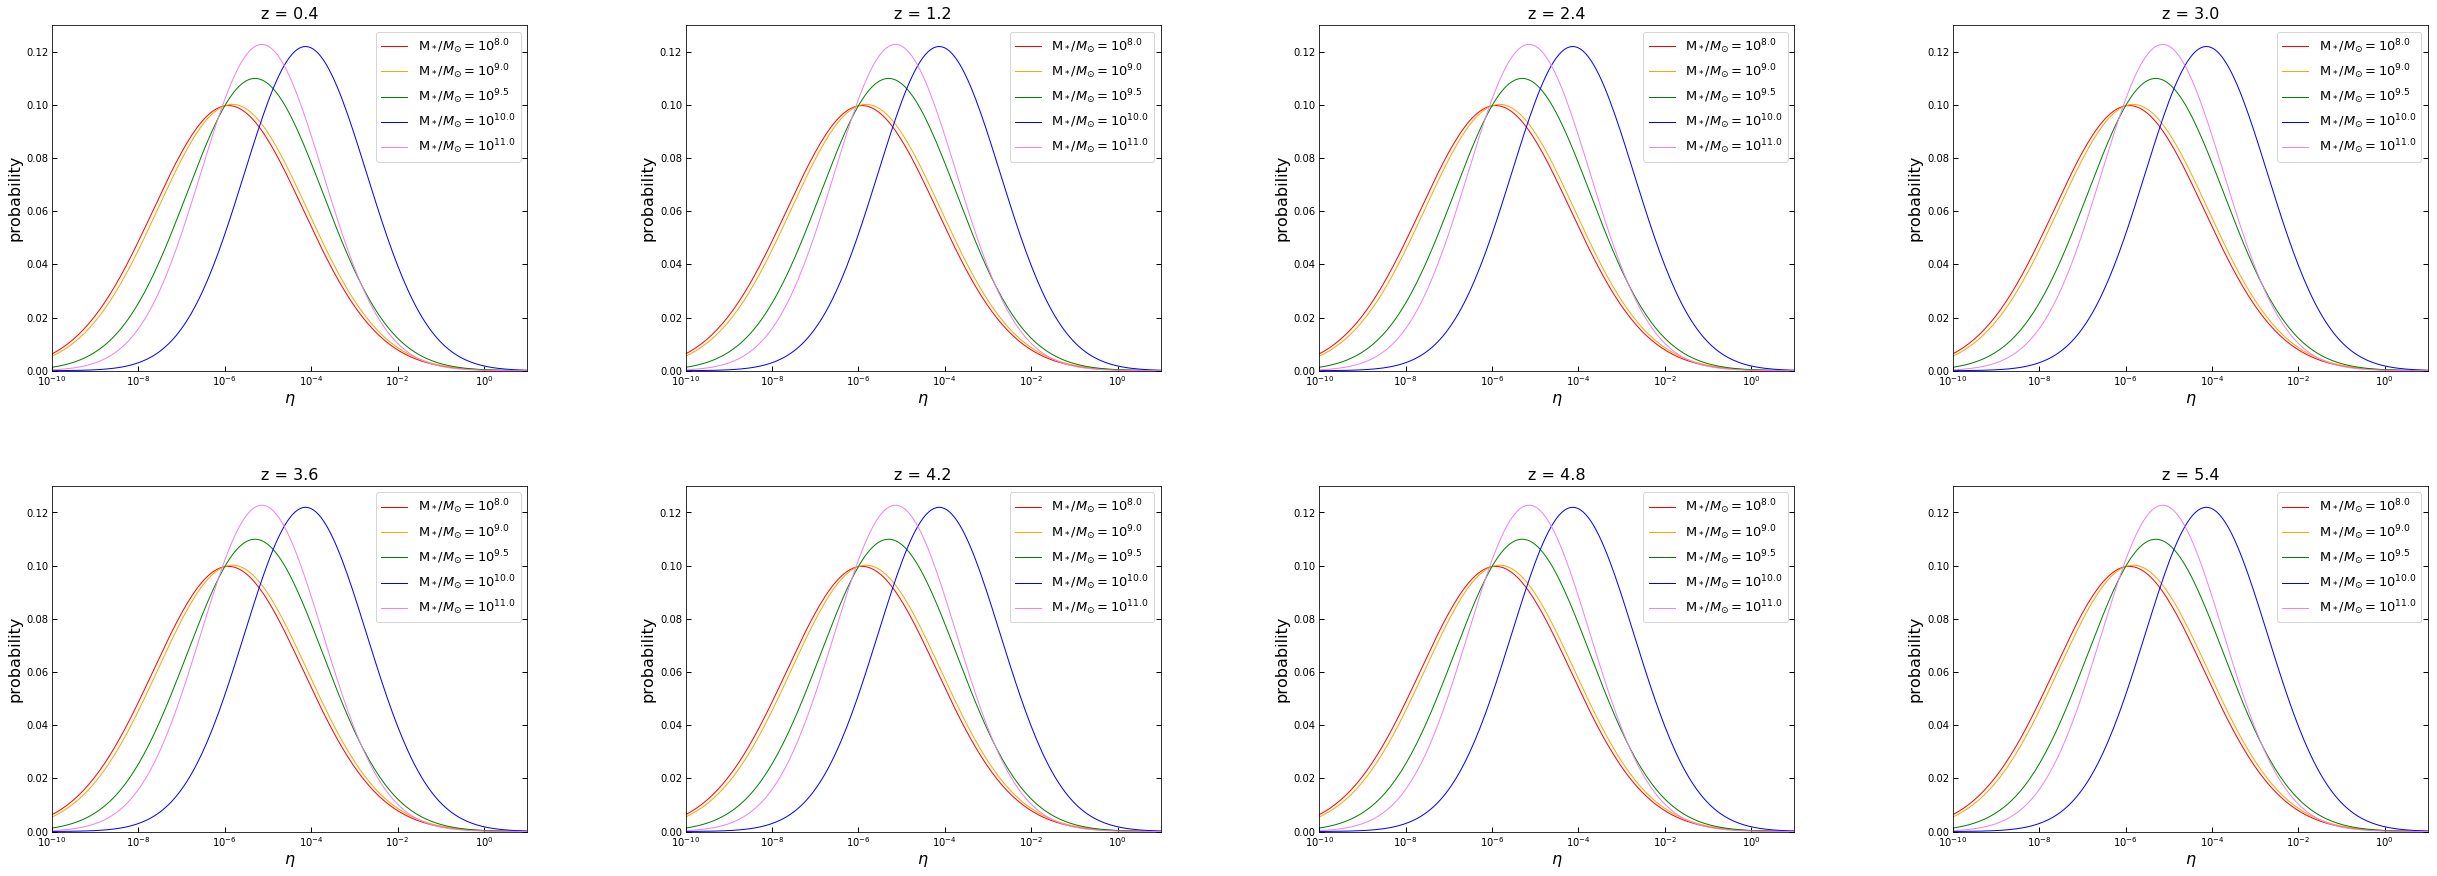

In [76]:
fig = plt.figure(figsize=(44,16))
zlist = [0.4, 1.2, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
color = ['r','orange','green','blue','violet']
dlnMstar = 0.7
bins = 0.005
start = 9.5
siglnX = [4.0, 3.25]
fs = 16
tw = 1
tl = 5
lw = 1.0
lums = np.linspace(5,18,200)
smass = np.array([8.0,9.0,9.5,10.0,11.0,12.0])

def plotdata(z, axis, axis_range, legend=True):
    ax = fig.add_axes(axis)
    qlf = QLF(zlist[0], bins)
    stell = qlf.StellBins
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(start, approx_local=True)
    qlf.get_dNdlnL(lums, siglnX)
    lnMdot = qlf.Mdot_mu_sig[:,0]
    sigs = qlf.Mdot_mu_sig[:,1]
    lnMdotedd = qlf.Mdot_mu_sig[:,2]
    lneta = lnMdot - lnMdotedd
    
    for mass, c in zip(smass, color):
        i = np.argmin(np.abs(stell - mass))
        x = np.linspace(-25, 3, 200)
        y = ( 1/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lneta[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )
        if legend == True:
            ax.plot(np.e**x, y, color=c, lw= lw, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
        else:
            ax.plot(np.e**x, y, color=c, lw= lw)
    if legend == True:
        ax.legend(loc='upper right',fontsize = 13)
    ax.set_xscale('log')
    ax.axis(axis_range)
    ax.tick_params(direction='in', width = tw, length = tl, right = True)
    ax.set_title('z = '+str(z),fontsize=fs)
    ax.set_ylabel('probability',fontsize=fs)
    ax.set_xlabel('$\eta$',fontsize=fs)
    
    
axis_list = [[0.1,0.6,0.15,0.3],[0.3,0.6,0.15,0.3],[0.5,0.6,0.15,0.3],[0.7,0.6,0.15,0.3],[0.1,0.2,0.15,0.3],[0.3,0.2,0.15,0.3],[0.5,0.2,0.15,0.3],[0.7,0.2,0.15,0.3]]
for z, axis in zip(zlist,axis_list):
    plotdata(z,axis,[10**-10,10**1, 0, 0.13])
plt.savefig('plots/paper-plots/eta-vs-mstar-varyz.pdf')

-

-

-

-

Plot displaying deconstructed QLF for low redshift values

-

-

-

-

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/font_manager.py:1328: UserWarning: findfont: Font family ['serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/font_manager.py:1328: UserWarning: findfont: Font family ['serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/font_manager.py:1328: UserWarn

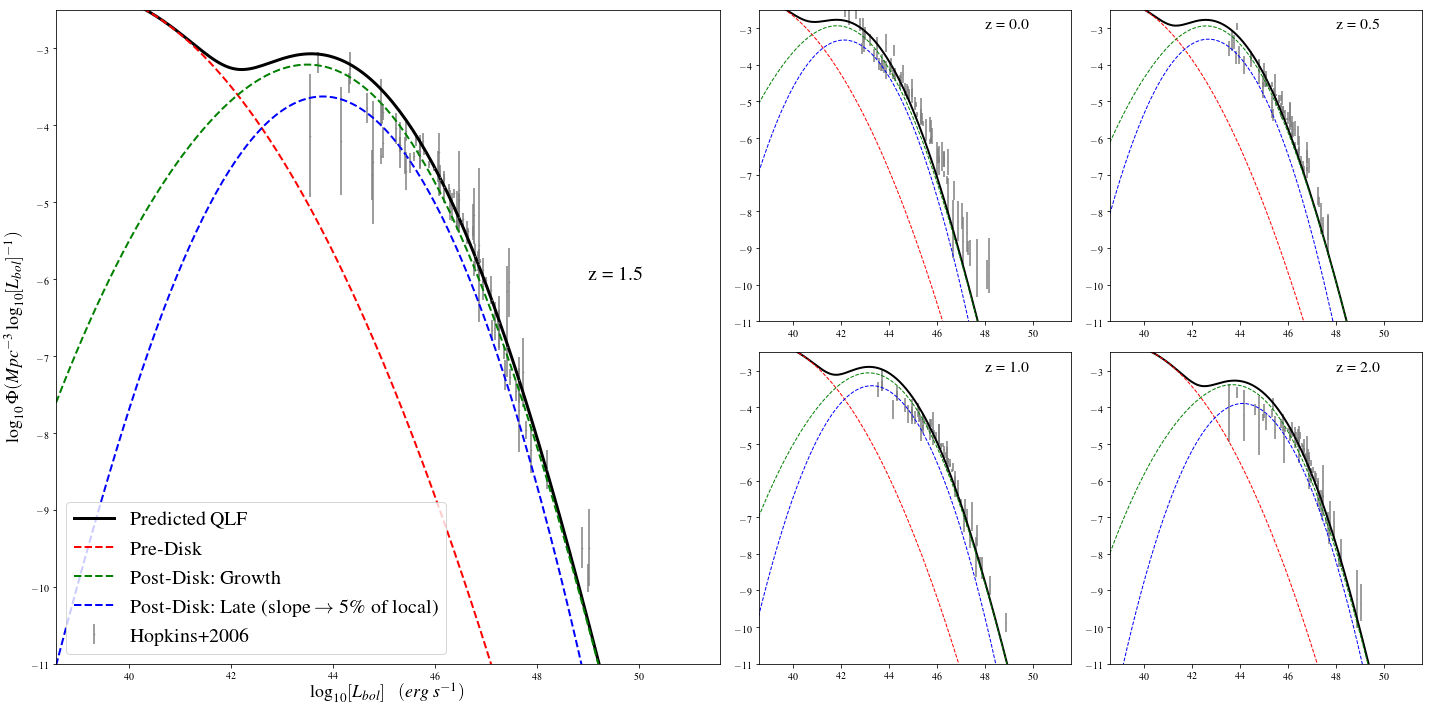

In [30]:
fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(2, 4)
lums = np.linspace(5,18,200)
z = 1.5
siglnX = [3.0, 2.0]
start = 10.0
ax1 = fig.add_subplot(gs[0:, 0:2])
qlf = QLF(z, 0.01)
qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)
xm, ym = lums + np.log10(3.8e33), np.log10(qlf.dNdlnL * np.log(10))
ax1.plot(xm, ym, c='k',lw=3, label='Predicted QLF')

    
prea = np.zeros(len(lumsp))
posta = np.zeros(len(lumsp))
latea = np.zeros(len(lumsp))
for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
    dens = i
    if pre == True:
        prea += dens
    elif m <= 1.05*1.12:
        latea += dens
    else:
        posta += dens

ax1.plot(xm, np.log10(np.asarray(prea) * np.log(10)), c='r', label='Pre-Disk',lw=2, linestyle='dashed')
ax1.plot(xm, np.log10(np.asarray(posta) * np.log(10)), c='green', label='Post-Disk: Growth',lw=2, linestyle='dashed')
ax1.plot(xm, np.log10(np.asarray(latea) * np.log(10)), c='b', label=r'Post-Disk: Late (slope $\to$ 5\% of local)',lw=2, linestyle='dashed')



x, y , yerr = grab_obs(z)
ax1.errorbar(x + np.log10(3.8e33), y, yerr = yerr, fmt = 'o', markersize = .5, c='gray', label = 'Hopkins+2006')

ax1.axis([min(xm),max(xm),-11,-2.5])
ax1.set_xlabel(r'$\log_{10} [L_{bol}] \ \ \ (erg \ s^{-1})$', fontsize=18)
ax1.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)
ax1.legend(fontsize = 20)
ax1.text(49,-6, 'z = '+str(z), fontsize = 20)


for z, i, j in zip([0.0,0.5,1.0,2.0],[0,0,1,1],[2,3,2,3]):
    ax = fig.add_subplot(gs[i, j], sharex = ax1, sharey = ax1)
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(start, approx_local=True)
    qlf.get_dNdlnL(lums, siglnX)
    xm, ym = lums + np.log10(3.8e33), np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k',lw=2)

    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))
    latea = np.zeros(len(lumsp))
    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        elif m <= 1.05*1.12:
            latea += dens
        else:
            posta += dens

    ax.plot(xm, np.log10(np.asarray(prea) * np.log(10)), c='r', label='Pre-Disk',lw=1, linestyle='dashed')
    ax.plot(xm, np.log10(np.asarray(posta) * np.log(10)), c='green', label='Post-Disk: Growth',lw=1, linestyle='dashed')
    ax.plot(xm, np.log10(np.asarray(latea) * np.log(10)), c='b', label=r'Post-Disk: Late (slope $\to$ 5\% of local)',lw=1, linestyle='dashed')


    x, y , yerr = grab_obs(z)
    ax.errorbar(x + np.log10(3.8e33), y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'Hopkins+2006')
    ax.axis([min(xm),max(xm),-11,-2.5])
    ax.text(48,-3, 'z = '+str(z), fontsize = 16)
plt.tight_layout()
plt.savefig('plots/paper-plots/QLF_eye-lowz_v2.0.pdf')

-

-

-

-

Plot displaying deconstructed QLF for a lot of redshift values

-

-

-

-

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


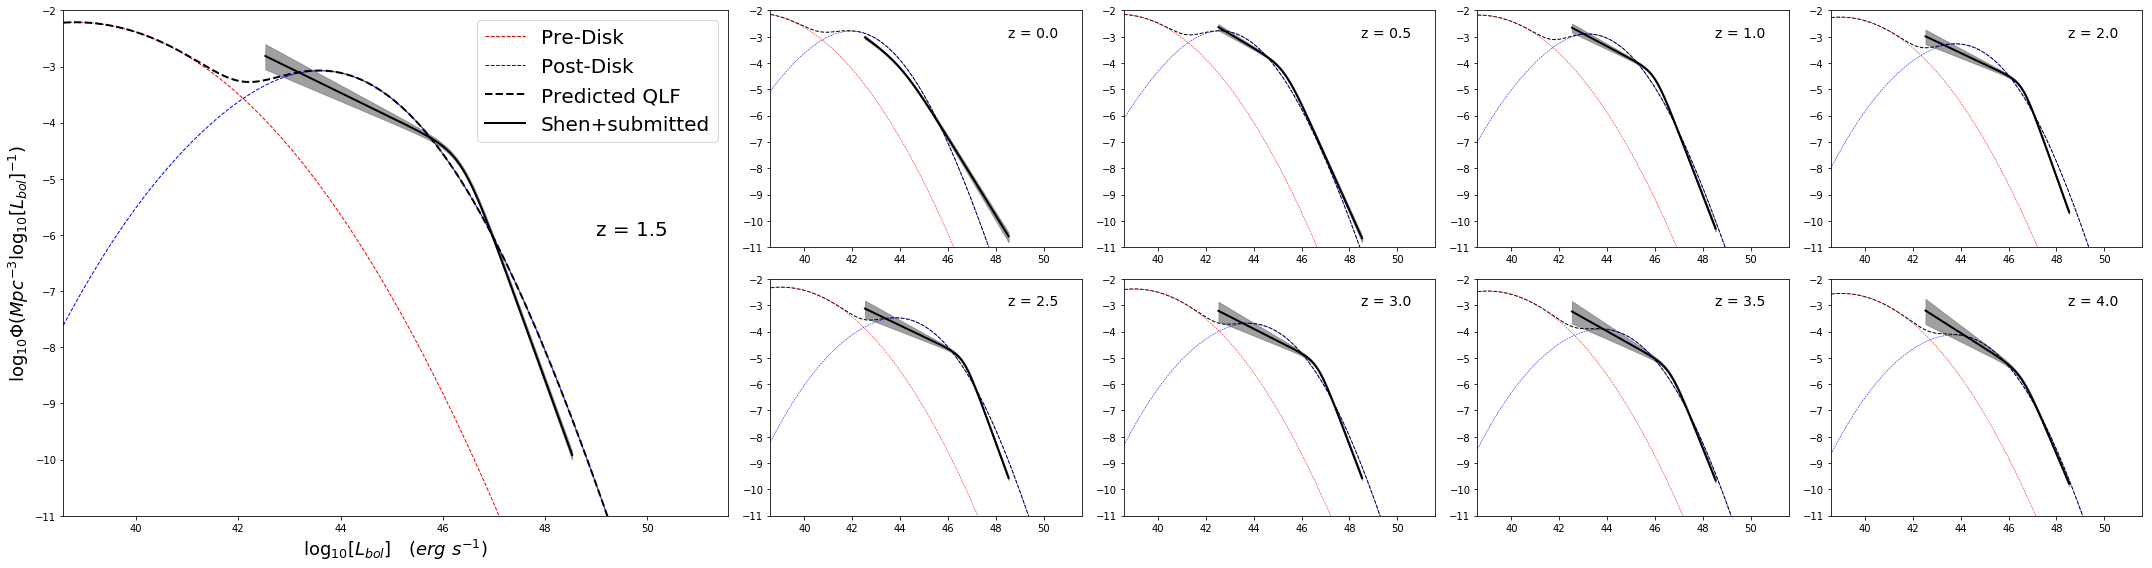

In [91]:
def shen_QLF(z, L):
    a0, a1, a2 = 0.85858, -0.26236, 0.02105
    b0, b1, b2 = 2*2.54992, -1.04735, 1.13277
    c0, c1, c2 = 2*13.01297, -0.57587, 0.45361
    d0, d1 = -3.53138, -0.39961
    zr = 2.0
    zfrac = (1 + z)/(1 + zr)
    g1 = C.chebval(1 + z, [a0, a1, a2])
    g2 = b0/(zfrac**b1 + zfrac **b2)
    logLs = c0/(zfrac**c1 + zfrac**c2)
    logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
    Lfrac = 10**L / 10**logLs
    Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)
    
    return np.log10(Phibol)

fig = plt.figure(figsize=(30,8))
gs = gridspec.GridSpec(2, 6)
lums = np.linspace(5,18,200)
lumsshen = np.linspace(8.95,14.95,200)
lumsp = 10**lums*3.8e33
z = 1.5
siglnX = [3.0, 2.0]
start = 10.0
ax1 = fig.add_subplot(gs[0:, 0:2])
qlf = QLF(z, 0.01)
qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)
xm, ym = lums + np.log10(3.8e33), np.log10(qlf.dNdlnL * np.log(10))

prea = np.zeros(len(lumsp))
posta = np.zeros(len(lumsp))
latea = np.zeros(len(lumsp))
for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
    dens = i
    if pre == True:
        prea += dens
#     elif m <= 1.05*1.12:
#         latea += dens
    else:
        posta += dens

ax1.plot(xm, np.log10(np.asarray(prea) * np.log(10)), c='r', label='Pre-Disk',lw=1, linestyle='dashed')
ax1.plot(xm, np.log10(np.asarray(posta) * np.log(10)), c='b', label='Post-Disk',lw=1, linestyle='dashed')
# ax1.plot(xm, np.log10(np.asarray(latea) * np.log(10)), c='b', label=r'Post-Disk: Late (slope $\to$ 5\% of local)',lw=1, linestyle='dashed')
ax1.plot(xm, ym, c='k',lw=2, label='Predicted QLF', linestyle='dashed')

dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen)
ax1.plot(lumsshen + np.log10(3.8e33), dens, label='Shen+submitted',c='black',linestyle='solid',lw = 2)
ax1.fill_between(lumsshen + np.log10(3.8e33), dens-stanab, dens+stanb, color='gray', alpha=.75)
ax1.axvline(xshen[0],c='k',linestyle='dotted')
ax1.axvline(xshen[-1],c='k',linestyle='dotted')

x, y , yerr = grab_obs(z)
# ax1.errorbar(x + np.log10(3.8e33), y, yerr = yerr, fmt = 'o', markersize = .5, c='gray', label = 'Hopkins+2006')

ax1.axis([min(xm),max(xm),-11,-2])
ax1.set_xlabel(r'$\log_{10} [L_{bol}] \ \ \ (erg \ s^{-1})$', fontsize=18)
ax1.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)
ax1.legend(fontsize = 20)
ax1.text(49,-6, 'z = '+str(z), fontsize = 20)


for z, i, j in zip([0.0,0.5,1.0,2.0,2.5,3.0,3.5,4.0],[0,0,0,0,1,1,1,1],[2,3,4,5,2,3,4,5]):
    ax = fig.add_subplot(gs[i, j], sharex = ax1, sharey = ax1)
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(start, approx_local=True)
    qlf.get_dNdlnL(lums, siglnX)
    xm, ym = lums + np.log10(3.8e33), np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k',lw=1,linestyle='dashed')

    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))
    latea = np.zeros(len(lumsp))
    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
#         elif m <= 1.05*1.12:
#             latea += dens
        else:
            posta += dens

    ax.plot(xm, np.log10(np.asarray(prea) * np.log(10)), c='r', label='Pre-Disk',lw=.5, linestyle='dashed')
    ax.plot(xm, np.log10(np.asarray(posta) * np.log(10)), c='b', label='Post-Disk',lw=.5, linestyle='dashed')
#     ax.plot(xm, np.log10(np.asarray(latea) * np.log(10)), c='b', label=r'Post-Disk: Late (slope $\to$ 5\% of local)',lw=.5, linestyle='dashed')
    
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen)
    ax.plot(lumsshen + np.log10(3.8e33), dens, label='Shen+submitted',c='black',linestyle='solid',lw = 2)
    ax.fill_between(lumsshen + np.log10(3.8e33), dens-stanab, dens+stanb, color='gray', alpha=.75)
    ax.axvline(xshen[0],c='k',linestyle='dotted')
    ax.axvline(xshen[-1],c='k',linestyle='dotted')

    x, y , yerr = grab_obs(z)
#     ax.errorbar(x + np.log10(3.8e33), y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'Hopkins+2006')
    ax.axis([min(xm),max(xm),-11,-2])
    ax.text(48.5,-3, 'z = '+str(z), fontsize = 14)
plt.tight_layout()
plt.savefig('plots/paper-plots/QLF_eye_lotz_v3.0.pdf')



/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


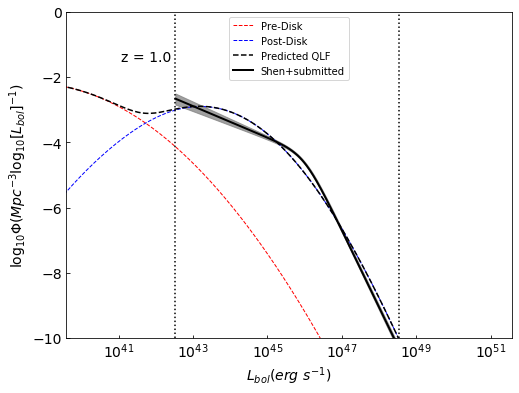

In [10]:
def shen_QLF(z, L):
    a0, a1, a2 = 0.85858, -0.26236, 0.02105
    b0, b1, b2 = 2*2.54992, -1.04735, 1.13277
    c0, c1, c2 = 2*13.01297, -0.57587, 0.45361
    d0, d1 = -3.53138, -0.39961
    zr = 2.0
    zfrac = (1 + z)/(1 + zr)
    g1 = C.chebval(1 + z, [a0, a1, a2])
    g2 = b0/(zfrac**b1 + zfrac **b2)
    logLs = c0/(zfrac**c1 + zfrac**c2)
    logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
    Lfrac = 10**L / 10**logLs
    Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)
    
    return np.log10(Phibol)


fig, ax = plt.subplots(1,1,figsize=(8,6))
z = 1.0
qlf = QLF(z, 0.005)
qlf.get_dNdlnMstar(0.7)
lums = np.linspace(5,18,200)
siglnX = [3.0, 2.0]
start = 10
qlf.get_Mbh(start, approx_local=True)

m = qlf.slopes

# %prun qlf.get_dNdlnL(lums, siglnX)
qlf.get_dNdlnL(lums, siglnX)
lumsp = 10**lums*3.8e33
prea = np.zeros(len(lumsp))
posta = np.zeros(len(lumsp))
latea = np.zeros(len(lumsp))
for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
    dens = i
    if pre == True:
        prea += dens
#     elif m <= 1.05*1.12:
#         latea += dens
    else:
        posta += dens

l1, = ax.plot(lumsp, np.log10(prea*np.log(10)), lw=1, c='r', linestyle='dashed')
l2, = ax.plot(lumsp, np.log10(posta*np.log(10)), lw=1, c='b', linestyle='dashed')
# # l3, = ax.plot(lumsp, np.log10(latea*np.log(10)), lw=1, c='b', linestyle='dashed')
l1.set_label('Pre-Disk')
l2.set_label('Post-Disk')
# l3.set_label(r'Post-Disk: Late (slope $\to$ 5\% of local)')

x,y,yerr = grab_obs(z)
# ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2006')

lumsshen = np.linspace(8.95,14.95,200)
xshen = 10**lumsshen*3.8e33
dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen)

ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='k', label = 'Predicted QLF',linestyle='dashed')
ax.plot(xshen, dens, label='Shen+submitted',c='k',lw=2)
ax.fill_between(xshen, dens-stanab, dens+stanb, color='gray', alpha=.75)
ax.axvline(xshen[0],c='k',linestyle='dotted')
ax.axvline(xshen[-1],c='k',linestyle='dotted')

ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=14)
ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =14)
# ax.text(10**8*3.8e33,-1.5,r'post-disk $\sigma_{\ln \rmX} = $'+str(siglnX[1]))
# ax.text(10**8*3.8e33,-1,r'pre-disk $\sigma_{\ln \rmX} = $'+str(siglnX[0]))
# ax.text(10**8*3.8e33,-2,r'$\rmM_{*0}/\rmM_{\odot} = 10^{'+str(start)+'}$')
ax.text(10**7.5*3.8e33,-1.5,'z = '+str(z),fontsize = 14)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax.legend()
plt.savefig('plots/paper-plots/cont_post-disk_v3.4.pdf')

-

-

-

-

Plot attempting to demonstrate the effects of varrying parameters on individual regime contributions to the QLF

-

-

-

-

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


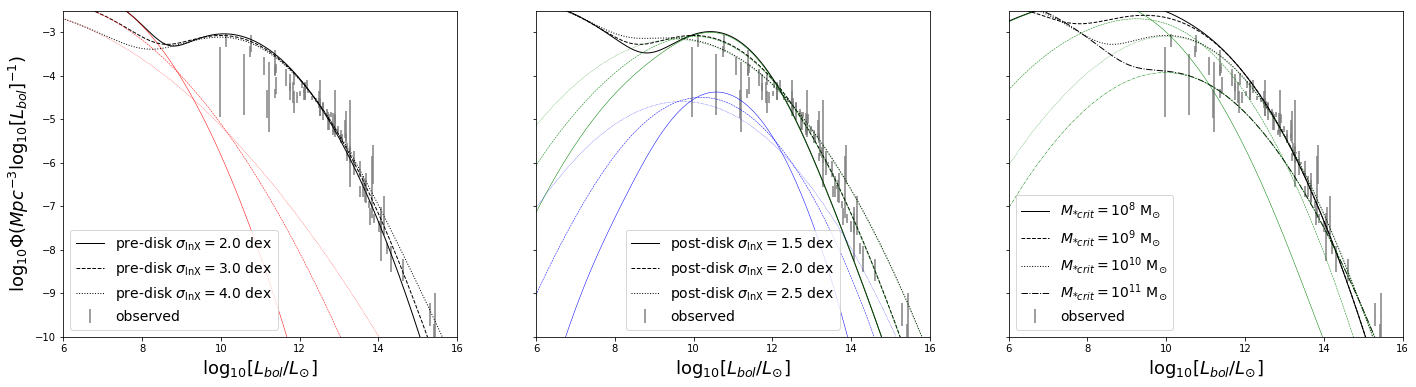

In [4]:
fig = plt.figure(figsize=(24,6))
gs = gridspec.GridSpec(1, 3)
lums = np.linspace(5,18,1000)
z = 1.5
qlf = QLF(z, 0.01)
x, y , yerr = grab_obs(z)
lines = ['solid','dashed','dotted','dashdot']
ax = fig.add_subplot(gs[0, 0])
for xsig1, ls in zip([2.0,3.0,4.0], lines):
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(10, approx_local=True)
    qlf.get_dNdlnL(lums, [xsig1, 2.0])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k',lw=1, label=r'pre-disk $\sigma_{\ln \rmX} = $'+str(xsig1)+' dex', ls = ls)

    totearly = []
    totgrowth = []
    totlate = []

    for i in qlf.intvals:
        totearly.append(np.sum(i[qlf.pre]))
        totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
        totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

    ax.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r',lw=0.5, ls=ls)
ax.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax.legend(fontsize=14)
ax.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)
ax.axis([6,16,-10,-2.5])


ax1 = fig.add_subplot(gs[0, 1], sharex = ax, sharey = ax)
for xsig2, ls in zip([1.5, 2.0, 2.5], lines):
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(10, approx_local=True)
    qlf.get_dNdlnL(lums, [3.0, xsig2])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax1.plot(xm, ym, c='k',lw=1, label=r'post-disk $\sigma_{\ln \rmX} = $'+str(xsig2)+' dex', ls = ls)

    totearly = []
    totgrowth = []
    totlate = []

    for i in qlf.intvals:
        totearly.append(np.sum(i[qlf.pre]))
        totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
        totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

    ax1.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green',lw=0.5,ls=ls)
    ax1.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b',lw=0.5, ls=ls)
ax1.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax1.legend(fontsize=14)
ax1.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax1.axis([6,16,-10,-2.5])


ax2 = fig.add_subplot(gs[0, 2], sharex = ax, sharey = ax)
for start, ls in zip([8,9,10, 11], lines):
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(start, approx_local=True)
    qlf.get_dNdlnL(lums, [3.0, 2.0])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax2.plot(xm, ym, c='k', lw=1, label=r'$M_{*crit} = 10^{'+str(start)+'}$ M$_{\odot}$', ls = ls)

    totearly = []
    totgrowth = []
    totlate = []

    for i in qlf.intvals:
        totearly.append(np.sum(i[qlf.pre]))
        totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
        totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

    ax2.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green',lw=0.5,ls=ls)

ax2.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax2.legend(fontsize=14)
ax2.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax2.axis([6,16,-10,-2.5])

plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.savefig('plots/paper-plots/free_param_effects_v2.0.pdf')

-

-

-

-

Plot for pre-disk post-disk chi2 grid comparison

-

-

-

-

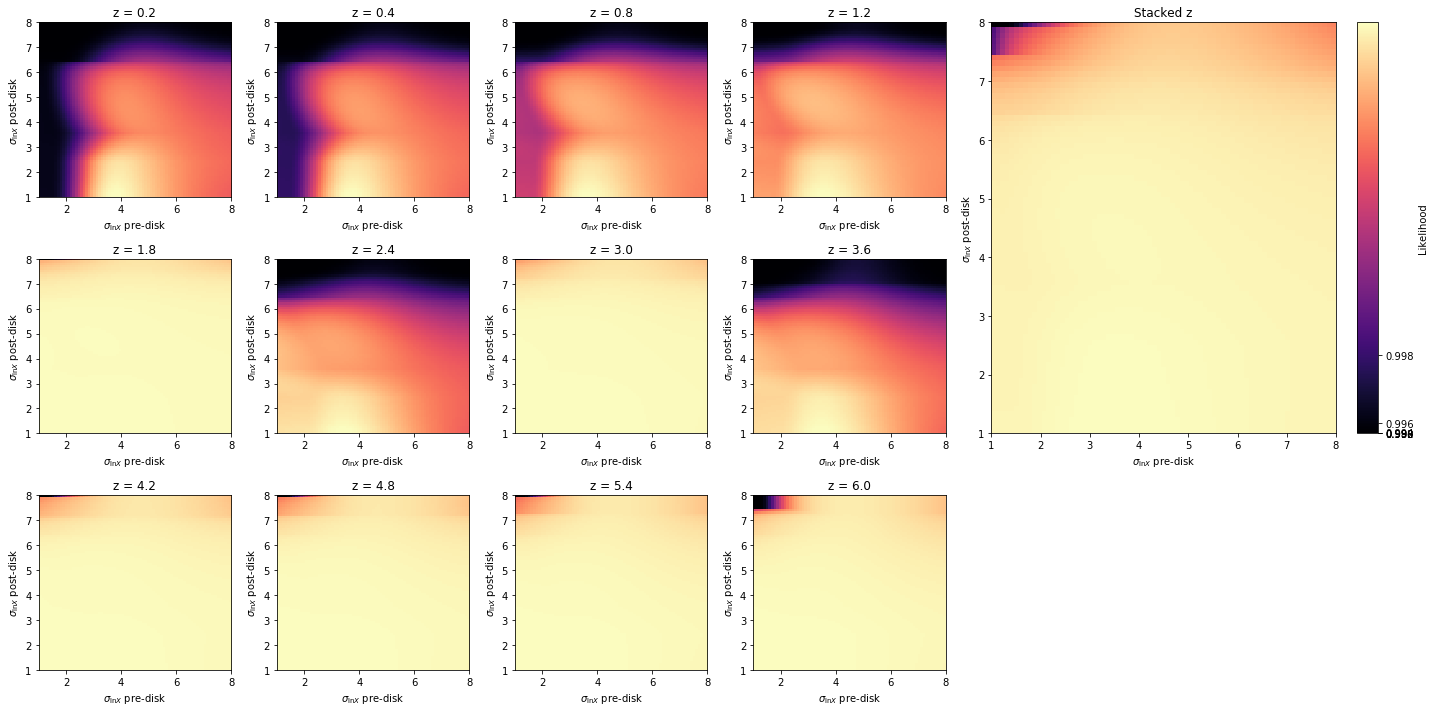

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import matplotlib.gridspec as gridspec
import matplotlib
# plt.close('all')

f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

prepost = True
prelogMstar0 = False
postlogMstar0 = False

# prepost = False
# prelogMstar0 = True
# postlogMstar0 = False

# prepost = False
# prelogMstar0 = False
# postlogMstar0 = True

fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 6)
stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,1,1,1,1,2,2,2,2],[0,1,2,3,0,1,2,3,0,1,2,3]):

    f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
    chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
    f.close()
    
    ax = fig.add_subplot(gs[i, j])
    
    #dM stuff
    Mchi2 = np.sum(chi23d, axis = (2,1))
#     maxM = max(Mchi2)
    maxM = sum(Mchi2)
    Mlike = np.e**(-Mchi2/maxM)
    
    #post stuff
    POchi2 = np.sum(chi23d, axis = (0,2))
#     maxPO = max(POchi2)
    maxPO = sum(POchi2)
    POlike = np.e**(-POchi2/maxPO)
    
    #pre stuff
    PRchi2 = np.sum(chi23d, axis = (0,1))
#     maxPR = max(PRchi2)
    maxPR = sum(PRchi2)
    PRlike = np.e**(-PRchi2/maxPR)
    
    #post-pre stuff
    if prepost == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 0))
#         maxV = max([maxPO,maxPR])
        maxV = maxPO+maxPR
        like = np.e**(-grid2d/maxV)
        xlabel = r'$\sigma_{\ln{X}}$ pre-disk'
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        file = 'pre-disk_vs_post-disk'
        axis = [1,8,1,8]
        extent = [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]
        
    elif prelogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 2))
#         maxV = max([maxPR,maxM])
        maxV = maxPR + maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ pre-disk'
        xlabel = 'logMstar0'
        file = 'pre-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX1[-1], siglnX1[0]]
        
    elif postlogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 1))
#         maxV = max([maxPO,maxM])
        maxV = maxPO+maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = 'logMstar0'
        file = 'post-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX2[-1], siglnX2[0]]

        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis(axis)
    img = ax.imshow(like, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
    ax.set_title('z = '+str(z))
    stack += like / len(zlist)
       
        

ax1 = fig.add_subplot(gs[0:2,4:])
total = ax1.imshow(stack, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
ax1.axis(axis)
ax1.set_title('Stacked z')
ax1.set_ylabel(ylabel)
ax1.set_xlabel(xlabel)
plt.tight_layout()
cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05)
# plt.savefig('plots/general-plots/chi2_3pShenFit_nw'+file+'.pdf')



-

-

-

-

Plot for Mstarcrit predisk chi2 grid comparison

-

-

-

-

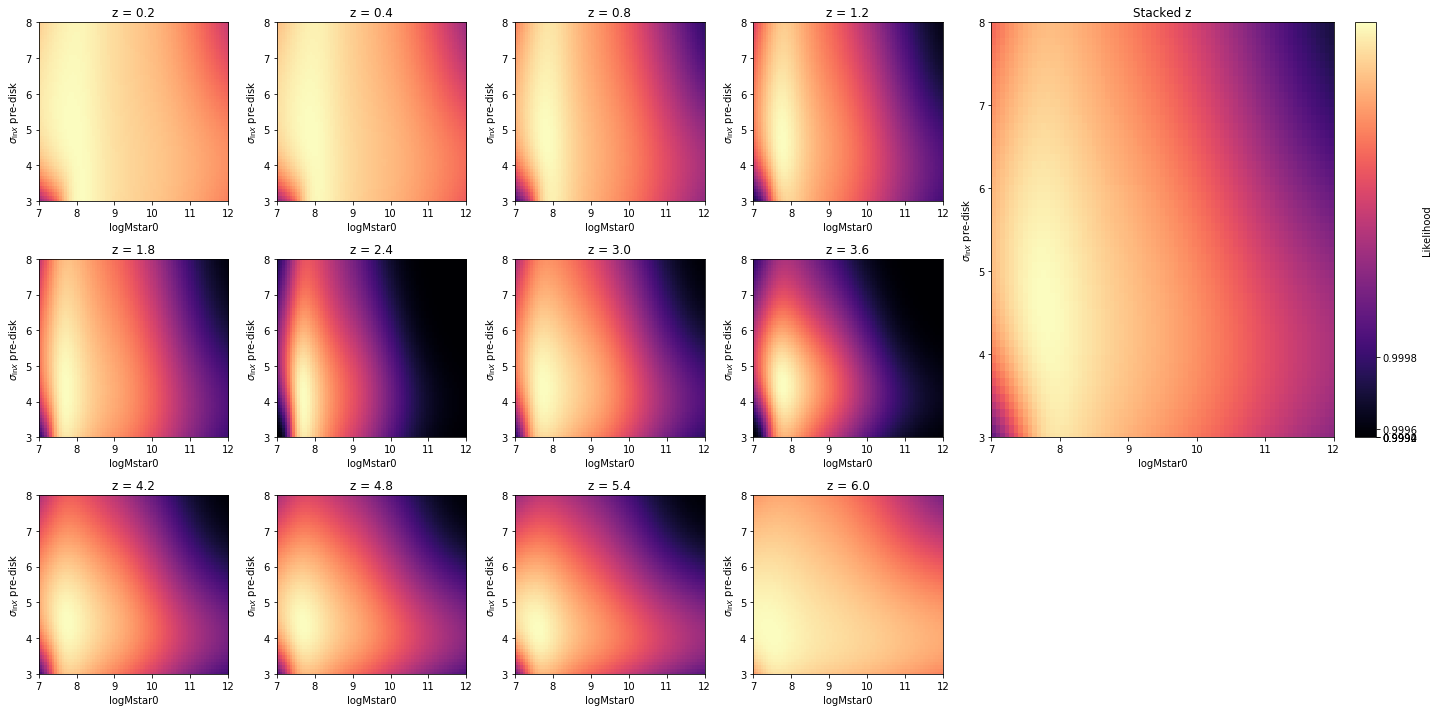

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import matplotlib.gridspec as gridspec
import matplotlib
# plt.close('all')

f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

# prepost = True
# prelogMstar0 = False
# postlogMstar0 = False

prepost = False
prelogMstar0 = True
postlogMstar0 = False

# prepost = False
# prelogMstar0 = False
# postlogMstar0 = True

fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 6)
stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,1,1,1,1,2,2,2,2],[0,1,2,3,0,1,2,3,0,1,2,3]):

    f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
    chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
    f.close()
    
    ax = fig.add_subplot(gs[i, j])
    
    #dM stuff
    Mchi2 = np.sum(chi23d, axis = (2,1))
#     maxM = max(Mchi2)
    maxM = sum(Mchi2)
    Mlike = np.e**(-Mchi2/maxM)
    
    #post stuff
    POchi2 = np.sum(chi23d, axis = (0,2))
#     maxPO = max(POchi2)
    maxPO = sum(POchi2)
    POlike = np.e**(-POchi2/maxPO)
    
    #pre stuff
    PRchi2 = np.sum(chi23d, axis = (0,1))
#     maxPR = max(PRchi2)
    maxPR = sum(PRchi2)
    PRlike = np.e**(-PRchi2/maxPR)
    
    #post-pre stuff
    if prepost == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 0))
#         maxV = max([maxPO,maxPR])
        maxV = maxPO+maxPR
        like = np.e**(-grid2d/maxV)
        xlabel = r'$\sigma_{\ln{X}}$ pre-disk'
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        file = 'pre-disk_vs_post-disk'
        axis = [1,8,1,8]
        extent = [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]
        
    elif prelogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 2))
#         maxV = max([maxPR,maxM])
        maxV = maxPR + maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ pre-disk'
        xlabel = 'logMstar0'
        file = 'pre-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX1[-1], siglnX1[0]]
        
    elif postlogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 1))
#         maxV = max([maxPO,maxM])
        maxV = maxPO+maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = 'logMstar0'
        file = 'post-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX2[-1], siglnX2[0]]

        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis(axis)
    img = ax.imshow(like, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
    ax.set_title('z = '+str(z))
    stack += like / len(zlist)
       
        

ax1 = fig.add_subplot(gs[0:2,4:])
total = ax1.imshow(stack, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
ax1.axis(axis)
ax1.set_title('Stacked z')
ax1.set_ylabel(ylabel)
ax1.set_xlabel(xlabel)
plt.tight_layout()
cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05)
# plt.savefig('plots/general-plots/chi2_3pShenFit_nw'+file+'.pdf')



-

-

-

-

Plot for mstarcrit postdisk chi2 grid comparisons

-

-

-

-

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import matplotlib.gridspec as gridspec
import matplotlib
# plt.close('all')

f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

# prepost = True
# prelogMstar0 = False
# postlogMstar0 = False

# prepost = False
# prelogMstar0 = True
# postlogMstar0 = False

prepost = False
prelogMstar0 = False
postlogMstar0 = True

fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 6)
stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,1,1,1,1,2,2,2,2],[0,1,2,3,0,1,2,3,0,1,2,3]):

    f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
    chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
    f.close()
    
    ax = fig.add_subplot(gs[i, j])
    
    #dM stuff
    Mchi2 = np.sum(chi23d, axis = (2,1))
#     maxM = max(Mchi2)
    maxM = sum(Mchi2)
    Mlike = np.e**(-Mchi2/maxM)
    
    #post stuff
    POchi2 = np.sum(chi23d, axis = (0,2))
#     maxPO = max(POchi2)
    maxPO = sum(POchi2)
    POlike = np.e**(-POchi2/maxPO)
    
    #pre stuff
    PRchi2 = np.sum(chi23d, axis = (0,1))
#     maxPR = max(PRchi2)
    maxPR = sum(PRchi2)
    PRlike = np.e**(-PRchi2/maxPR)
    
    #post-pre stuff
    if prepost == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 0))
#         maxV = max([maxPO,maxPR])
        maxV = maxPO+maxPR
        like = np.e**(-grid2d/maxV)
        xlabel = r'$\sigma_{\ln{X}}$ pre-disk'
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        file = 'pre-disk_vs_post-disk'
        axis = [1,8,1,8]
        extent = [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]
        
    elif prelogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 2))
#         maxV = max([maxPR,maxM])
        maxV = maxPR + maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ pre-disk'
        xlabel = 'logMstar0'
        file = 'pre-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX1[-1], siglnX1[0]]
        
    elif postlogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 1))
#         maxV = max([maxPO,maxM])
        maxV = maxPO+maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = r'$\log_{10}[M_{*\rm{crit}}] (M_{\odot})$'
        file = 'post-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX2[-1], siglnX2[0]]

        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis(axis)
    img = ax.imshow(like, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
    ax.set_title('z = '+str(z))
    stack += like / len(zlist)
       
        

ax1 = fig.add_subplot(gs[0:2,4:])
total = ax1.imshow(stack, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
ax1.axis(axis)
ax1.set_title('Stacked z')
ax1.set_ylabel(ylabel)
ax1.set_xlabel(xlabel)
plt.tight_layout()
cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05)
plt.savefig('plots/paper-plots/chi2_3pShenFit_nw'+file+'.pdf')



FigureCanvasNbAgg()

-

-

-

-

Plot for postdisk Mstarcrit comparison at the most probable value of predisk

-

-

-

-

logMstar0
siglnX1
siglnX2
z=0.2
z=0.4
z=0.8
z=1.2
z=1.8
z=2.4
z=3.0
z=3.6
z=4.2
z=4.8
z=5.4
z=6.0


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/contour.py:960: UserWarning: The following kwargs were not used by contour: 'lw'
  s)


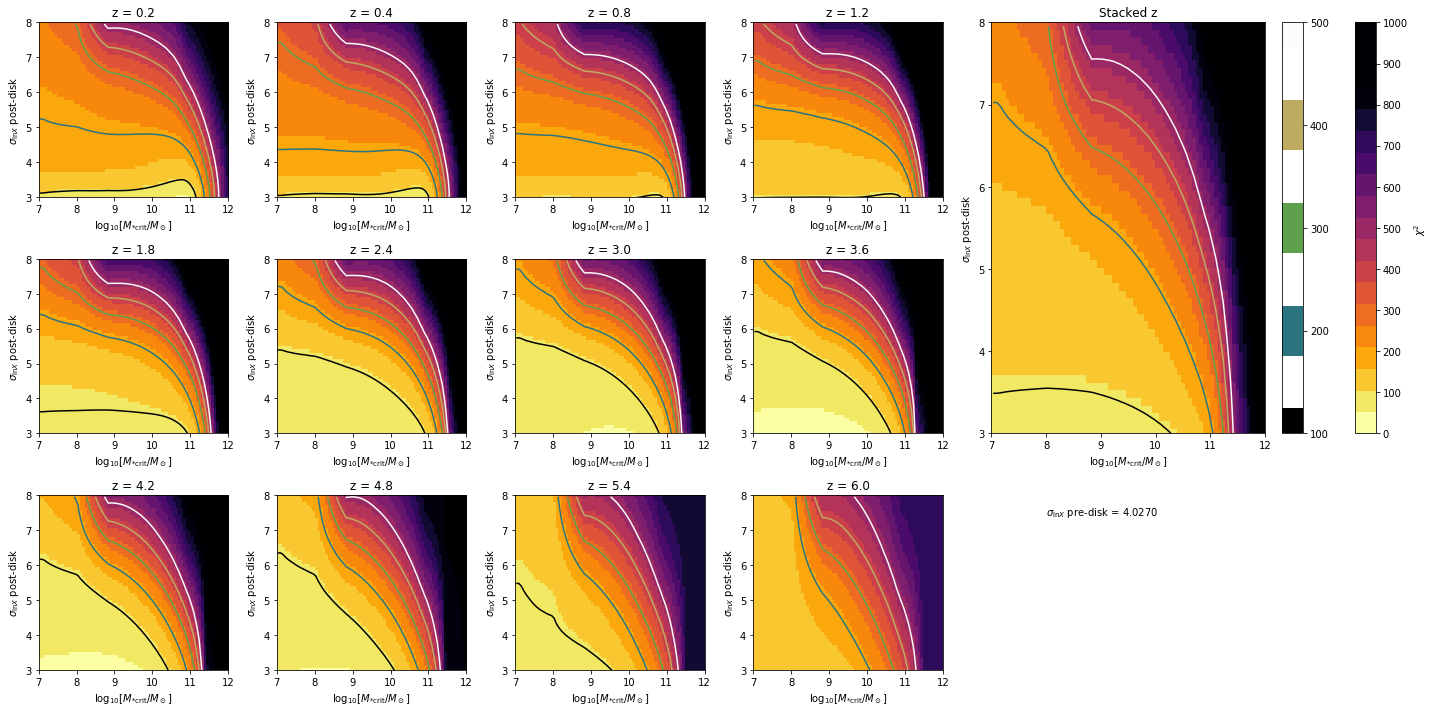

In [58]:
f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
for i in f:
    print(i)
f.close()

fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 6)
stack = np.zeros((len(logMstar0 ), len(logMstar0 )))

# pred = np.sum(chi23d, axis=(0,2))
# minpre =  min(np.sum(chi23d, axis=(0,2)))
# prein = np.where(pred == minpre)[0][0]

zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,1,1,1,1,2,2,2,2],[0,1,2,3,0,1,2,3,0,1,2,3]):

    f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
    chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
    f.close()
    
    pred = np.sum(chi23d, axis=(0,2))
    minpre =  min(np.sum(chi23d, axis=(0,2)))
    prein = np.where(pred == minpre)[0][0]
    
    ax = fig.add_subplot(gs[i, j])
    
    #dM stuff
    Mchi2 = np.sum(chi23d, axis = (2,1))
    maxM = sum(Mchi2)
    Mlike = np.e**(-Mchi2/maxM)
    
    #post stuff
    POchi2 = np.sum(chi23d, axis = (0,2))
    maxPO = sum(POchi2)
    POlike = np.e**(-POchi2/maxPO)
    

    grid2d = np.transpose(np.sum(chi23d, axis = 1))
    maxV = maxPO+maxM
    like = np.e**(-grid2d)
    ylabel = r'$\sigma_{\ln{X}}$ post-disk'
    xlabel = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
    file = 'post-disk_vs_logMstar0'
    axis = [7,12,3,8]
    extent = [logMstar0 [0], logMstar0 [-1], siglnX2[-1], siglnX2[0]]

    cmap = 'cubehelix_r'
    cmap = 'inferno_r'
    grid2d = chi23d[:,prein,:]
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis(axis)
    img = ax.imshow(grid2d, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.BoundaryNorm(boundaries=np.linspace(0,1000,20), ncolors=300),vmin = 0, vmax=1000)
    ax.set_title('z = '+str(z))
    ax.contour(grid2d, extent = extent, origin = 'image',lw=.25,levels=[100,200,300,400,500],cmap='gist_earth')
    stack += (grid2d) / len(zlist)
    
#     plt.text(8,2,'$\sigma_{\ln{X}}$ pre-disk = '+str(siglnX1[prein])[:6])

pred = np.sum(chi23d, axis=(0,2))
minpre =  min(np.sum(chi23d, axis=(0,2)))

ax1 = fig.add_subplot(gs[0:2,4:])
total = ax1.imshow(stack, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.BoundaryNorm(boundaries=np.linspace(0,1000,20), ncolors=300),vmin = 0, vmax=1000)
cont = ax1.contour(stack, extent = extent, origin = 'image',lw=.25,levels=[100,200,300,400,500],cmap='gist_earth')
ax1.axis(axis)## 44 256
ax1.set_title('Stacked z')
ax1.set_ylabel(ylabel)
ax1.set_xlabel(xlabel)
plt.tight_layout()
cbar = plt.colorbar(total, label=r'$\chi ^2$ ', pad = 0.05, ticks = [0,100,200,300,400,500,600,700,800,900,1000])
cbar = plt.colorbar(cont, pad = 0.05)
lines = cbar.ax.get_children()[0]
lines.set_linewidths([50]*len(lines.get_linewidths()))
plt.text(8,2,'$\sigma_{\ln{X}}$ pre-disk = '+str(siglnX1[prein])[:6])
plt.savefig('plots/paper-plots/chi2_ShenFit_nw'+file+'v2.0.pdf')




/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:54: RuntimeWarning: divide by zero encountered in log


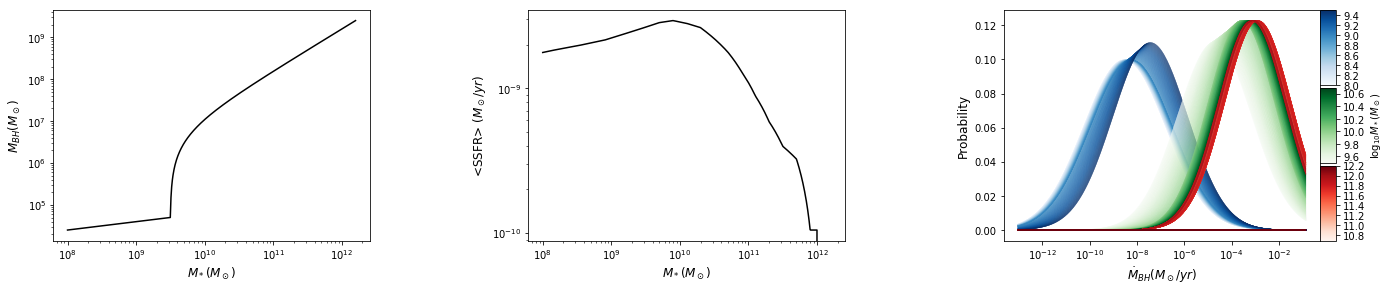

In [27]:
pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 9.5, 0.005
fs, lw = 12, 2
lums = np.linspace(5,18,200)
z = 2

qlf = QLF(z, b)
qlf.get_dNdlnMstar(lnM)
qlf.get_Mbh(Mcrit, approx_local=True)
qlf.get_dNdlnL(lums, [pre, post])

sigs = qlf.Mdot_mu_sig[:,1] #std on MbhdotX distributions
MbhdotX = np.e**qlf.Mdot_mu_sig[:,0]/(3.17098e-8*2e33) #solar mass per year w/ X model
Mbhdot = np.e**qlf.Mdot_mu_sig[:,3]/(3.17098e-8*2e33) #solar mass per year w/o X model
Ms = 10**qlf.StellBins #stellar mass in solar mass
Mbh = 10**qlf.BHBins #BH mass in solar mass
ssfr = np.e**qlf.Mdot_mu_sig[:,5]  #solar mass per year
LbX = 0.1 * (2.99e10)**2 * (MbhdotX / 3.154e7) * 2e33 #erg/s
Lb = 0.1 * (2.99e10)**2 * (Mbhdot / 3.154e7) * 2e33 #erg/s
prei = qlf.pre
posti = qlf.post
slopes = qlf.slopes
Mloc = np.log10(Ms[np.argmin(np.abs(slopes[posti]-0.95))])

fig = plt.figure(figsize=(22,8))
ax = fig.add_axes([0.0, 0.5, 0.2, 0.4])
ax.plot(Ms, Mbh, c='k')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel(r'$M_{BH} (M_\odot)$',fontsize=fs)
ax.set_xlabel(r'$M_* (M_\odot)$',fontsize=fs)

ax = fig.add_axes([0.3,0.5,0.2,0.4])
ax.plot(Ms, ssfr, c='k')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel(r'<SSFR> $(M_\odot /yr)$',fontsize=fs)
ax.set_xlabel(r'$M_* (M_\odot)$',fontsize=fs)

ax = fig.add_axes([0.6,0.5,0.2,0.4])

ax.set_ylabel('Probability',fontsize=fs)
ax.set_xlabel(r'$\dot{M}_{BH} (M_\odot /yr)$',fontsize=fs)
ax.set_xscale('log')
x = np.linspace(-30, -2, 200)

cmape = plt.cm.Blues
norme = matplotlib.colors.Normalize(vmin=min(np.log10(Ms)), vmax=Mcrit)
cmapg = plt.cm.Greens
normg = matplotlib.colors.Normalize(vmin=Mcrit, vmax=Mloc)
cmapl = plt.cm.Reds
norml = matplotlib.colors.Normalize(vmin=Mloc, vmax=max(np.log10(Ms)))


for mass, s, m in zip(np.log10(Ms), sigs, np.log(MbhdotX)):
    y = ( 1/np.sqrt(2.0 * np.pi * s**2.0) ) * np.exp( -(x - m)**2.0 / (2.0 * s**2) )
    if mass < Mcrit:
        ax.plot(np.e**x,y,color=cmape(norme(mass)),lw=0.25)
    elif mass > Mloc:
        ax.plot(np.e**x,y,color=cmapl(norml(mass)),lw=0.25)
    else:
        ax.plot(np.e**x,y,color=cmapg(normg(mass)),lw=0.25)
axe = fig.add_axes([0.8,0.77,0.01,0.13])
axg = fig.add_axes([0.8,0.635,0.01,0.13])
axl = fig.add_axes([0.8,0.500,0.01,0.13])
sm = plt.cm.ScalarMappable(cmap=cmape, norm=norme)
sm.set_array([])
fig.colorbar(sm, cax = axe)
sm = plt.cm.ScalarMappable(cmap=cmapg, norm=normg)
sm.set_array([])
fig.colorbar(sm, cax = axg, label=r'$\log_{10} M_* (M_\odot)$')
sm = plt.cm.ScalarMappable(cmap=cmapl, norm=norml)
sm.set_array([])
fig.colorbar(sm, cax = axl)



In [21]:
pre, post, lnM, Mcrit, b = 3, 2, 0.7, 9.5, 0.005
fs, lw, skip = 12, 2, 3
lums = np.linspace(5,18,200)
ticks = [7.0,7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0,11.5,12.0]
init = 0.1
fig = plt.figure(figsize=(22,8))
for z in [1.0,1.5,2.0]:

    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(lnM)
    qlf.get_Mbh(Mcrit, approx_local=True)
    qlf.get_dNdlnL(lums, [pre, post])

    sigs = qlf.Mdot_mu_sig[:,1] #std on MbhdotX distributions
    MbhdotX = np.e**qlf.Mdot_mu_sig[:,0]/(3.17098e-8*2e33) #solar mass per year w/ X model
    Ms = qlf.StellBins #stellar mass in solar mass
    lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
    prei = qlf.pre
    posti = qlf.post
    slopes = qlf.slopes
    Mloc = Ms[np.argmin(np.abs(slopes[posti]-0.95))]

    cmape = plt.cm.Blues
    norme = matplotlib.colors.Normalize(vmin=min(Ms)-1, vmax=Mcrit)
    cmapg = plt.cm.Greens
    normg = matplotlib.colors.Normalize(vmin=Mcrit-1, vmax=Mloc)
    cmapl = plt.cm.Reds
    norml = matplotlib.colors.Normalize(vmin=Mloc-1, vmax=max(Ms))

    ax = fig.add_axes([init, 0.55, 0.2, 0.35])
    ax.set_ylabel('Probability',fontsize=fs)
    ax.set_xlabel(r'$\eta$',fontsize=fs)
    ax.set_xscale('log')
    ax.set_title('z = '+str(z))
    x = np.linspace(-24, 5, 200)
    count0 = 0
    masses0 = []
    for mass, s, m in zip(Ms[::skip], sigs[::skip], lneta[::skip]):
        y = ( 1/np.sqrt(2.0 * np.pi * s**2.0) ) * np.exp( -(x - m)**2.0 / (2.0 * s**2) )
        if not y.any():
            count0 += 1
            masses0.append(mass)
        else:
            if mass < Mcrit:
                ax.plot(np.e**x,y,color=cmape(norme(mass)),lw=0.25)
            elif mass > Mloc:
                ax.plot(np.e**x,y,color=cmapl(norml(mass)),lw=0.25)
            else:
                ax.plot(np.e**x,y,color=cmapg(normg(mass)),lw=0.25)
    print('Skipped '+str(count0)+' mass bins for having all 0 eta values.')
    if count0 != 0:
        print(masses0[0], masses0[-1])
    
    axl = fig.add_axes([init+.205, 0.55+0.245, 0.01, 0.1])
    axg = fig.add_axes([init+.205, 0.55+0.125, 0.01, 0.1])
    axe = fig.add_axes([init+.205, 0.55+0.005, 0.01, 0.1])
    sm = plt.cm.ScalarMappable(cmap=cmape, norm=norme)
    sm.set_array([])
    fig.colorbar(sm, cax = axe, ticks = ticks)
    sm = plt.cm.ScalarMappable(cmap=cmapg, norm=normg)
    sm.set_array([])
    fig.colorbar(sm, cax = axg, label=r'$\log_{10} M_* (M_\odot)$', ticks = ticks)
    sm = plt.cm.ScalarMappable(cmap=cmapl, norm=norml)
    sm.set_array([])
    fig.colorbar(sm, cax = axl, ticks = ticks)
    init += 0.3

init = 0.1
for z in [3.6,4.8,6.0]:
    
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(lnM)
    qlf.get_Mbh(Mcrit, approx_local=True)
    qlf.get_dNdlnL(lums, [pre, post])

    sigs = qlf.Mdot_mu_sig[:,1] #std on MbhdotX distributions
    MbhdotX = np.e**qlf.Mdot_mu_sig[:,0]/(3.17098e-8*2e33) #solar mass per year w/ X model
    Ms = qlf.StellBins #stellar mass in solar mass
    lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
    prei = qlf.pre
    posti = qlf.post
    slopes = qlf.slopes
    Mloc = Ms[np.argmin(np.abs(slopes[posti]-0.95))]

    cmape = plt.cm.Blues
    norme = matplotlib.colors.Normalize(vmin=min(Ms)-1, vmax=Mcrit)
    cmapg = plt.cm.Greens
    normg = matplotlib.colors.Normalize(vmin=Mcrit-1, vmax=Mloc)
    cmapl = plt.cm.Reds
    norml = matplotlib.colors.Normalize(vmin=Mloc-1, vmax=max(Ms))
    
    ax = fig.add_axes([init,0.1,0.2,0.35])
    ax.set_ylabel('Probability',fontsize=fs)
    ax.set_xlabel(r'$\eta$',fontsize=fs)
    ax.set_xscale('log')
    ax.set_title('z = '+str(z))
    count0 = 0
    masses0 = []
    for mass, s, m in zip(Ms[::skip], sigs[::skip], lneta[::skip]):
        y = ( 1/np.sqrt(2.0 * np.pi * s**2.0) ) * np.exp( -(x - m)**2.0 / (2.0 * s**2) )
        if not y.any():
            count0 += 1
            masses0.append(mass)
        else:
            if mass < Mcrit:
                ax.plot(np.e**x,y,color=cmape(norme(mass)),lw=0.25)
            elif mass > Mloc:
                ax.plot(np.e**x,y,color=cmapl(norml(mass)),lw=0.25)
            else:
                ax.plot(np.e**x,y,color=cmapg(normg(mass)),lw=0.25)
    print('Skipped '+str(count0)+' mass bins for having all 0 eta values.')
    if count0 != 0:
        print(masses0[0], masses0[-1])
        
    axl = fig.add_axes([init+.205, 0.1+0.245, 0.01, 0.1])
    axg = fig.add_axes([init+.205, 0.1+0.125, 0.01, 0.1])
    axe = fig.add_axes([init+.205, 0.1+0.005, 0.01, 0.1])
    sm = plt.cm.ScalarMappable(cmap=cmape, norm=norme)
    sm.set_array([])
    fig.colorbar(sm, cax = axe, ticks = ticks)
    sm = plt.cm.ScalarMappable(cmap=cmapg, norm=normg)
    sm.set_array([])
    fig.colorbar(sm, cax = axg, label=r'$\log_{10} M_* (M_\odot)$', ticks = ticks)
    sm = plt.cm.ScalarMappable(cmap=cmapl, norm=norml)
    sm.set_array([])
    fig.colorbar(sm, cax = axl, ticks = ticks)  
    init += 0.3

# plt.tight_layout()
plt.savefig('plots/paper-plots/eta_vs_sm-varyz_v2.2.pdf')

FigureCanvasNbAgg()

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


Skipped 13 mass bins for having all 0 eta values.
12.014558472553698 12.194988066825776
Skipped 13 mass bins for having all 0 eta values.
12.014558472553698 12.194988066825776
Skipped 13 mass bins for having all 0 eta values.
12.014558472553698 12.194988066825776
Skipped 0 mass bins for having all 0 eta values.
Skipped 13 mass bins for having all 0 eta values.
12.014558472553698 12.194988066825776
Skipped 40 mass bins for having all 0 eta values.
11.608591885441527 12.194988066825776


/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:24: RuntimeWarning: invalid value encountered in double_scalars


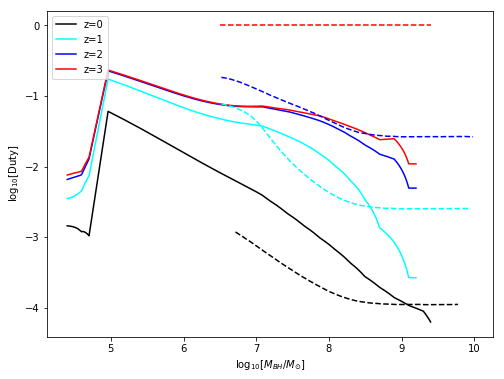

In [55]:
#### if a BH is accreting at its eddington luminsotiy it is considered active
import pandas as pd

pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 9.5, 0.005
lums = np.linspace(5,18,200)
init = 0.1
fig = plt.figure(figsize=(8,6))
colors = ['k','cyan','b','r']
for z,c in zip([0,1,2,3],colors):
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(lnM)
    qlf.get_Mbh(Mcrit, approx_local=True)
    qlf.get_dNdlnL(lums, [pre, post])

    lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
    sigs = qlf.Mdot_mu_sig[:,1] 
    lnbh = qlf.BHBins
    duty = []
    x = np.linspace(-25, 2, 2000)
    for mass, s, m in zip(lnbh, sigs, lneta):
        y = ( 1/np.sqrt(2.0 * np.pi * s**2.0) ) * np.exp( -(x - m)**2.0 / (2.0 * s**2) )
        tot = np.sum(y)
        frac = np.sum(y[np.e**x>=0.1])
        duty.append(frac/tot)
    plt.plot(lnbh,np.log10(duty),label="z="+str(z),c=c)
    
plt.legend(loc='upper left')
z0 = pd.read_csv("plot_data/marconiz0.csv",names=['x','y'])
plt.plot(z0['x'],z0['y'],color = colors[0],ls='dashed')
z1 = pd.read_csv("plot_data/marconiz1.csv",names=['x','y'])
plt.plot(z1['x'],z1['y'],color = colors[1],ls='dashed')
z2 = pd.read_csv("plot_data/marconiz2.csv",names=['x','y'])
plt.plot(z2['x'],z2['y'],color = colors[2],ls='dashed')
plt.plot([6.5,lnbh[-1]],[0,0],c=colors[3],ls='dashed')

plt.xlabel(r'$\log_{10}[M_{BH}/M_{\odot}]$')
plt.ylabel('$\log_{10}$[Duty]')
# plt.axis([4,10,-5,-1])
plt.savefig('plots/general-plots/dutycyc_vs_mbh_v0.1.pdf')

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


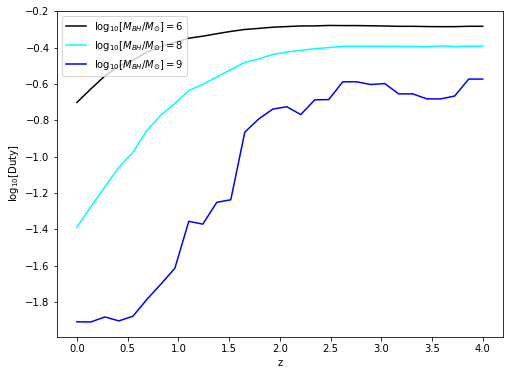

In [67]:
#### if a BH is accreting at its eddington luminsotiy it is considered active
pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 9.5, 0.005
lums = np.linspace(5,18,200)
init = 0.1
fig = plt.figure(figsize=(8,6))
colors = ['k','cyan','b','r']
zs = np.linspace(0,4,30)
for M, c in zip([6,8,9],colors):
    duty = []
    for z in zs:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(lnM)
        qlf.get_Mbh(Mcrit, approx_local=True)
        qlf.get_dNdlnL(lums, [pre, post])

        lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
        sigs = qlf.Mdot_mu_sig[:,1] 
        lnbh = qlf.BHBins
        x = np.linspace(-25, 2, 2000)
        ind = np.argmin(np.abs(lnbh - M))
        y = ( 1/np.sqrt(2.0 * np.pi * sigs[ind]**2.0) ) * np.exp( -(x - lneta[ind])**2.0 / (2.0 * sigs[ind]**2) )
        tot = np.sum(y)
        frac = np.sum(y[np.e**x>=0.001])
        duty.append(frac/tot)
    plt.plot(zs,np.log10(duty),label=r"$\log_{10}[M_{BH}/M_{\odot}]=$"+str(M) ,c=c)
    
plt.legend(loc='upper left')
plt.xlabel(r'z')
plt.ylabel('$\log_{10}$[Duty]')
plt.savefig('plots/general-plots/dutycyc_vs_mbh_v1.1.pdf')

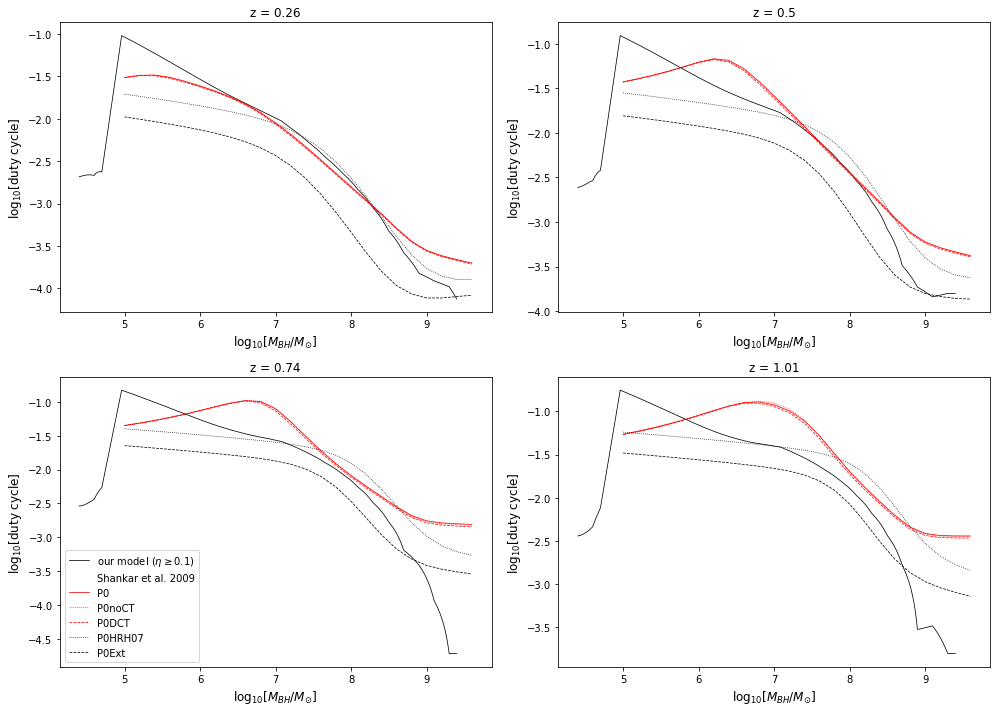

In [27]:
duty = np.loadtxt("plot_data/shakar2009dutycycle.txt")
z_list = duty[:,0]
logM = duty[:,1]
P0 = duty[:,2] ##reference model
P0noCT = duty[:,3] ##reference w/o compton thick (basically lower epsilon)
P0DCT = duty[:,4] ##double compton thick (basically just raise epsilon)
P0HRH07 = duty[:,5] ##Hopkins 2007 prediction
P0Ext = duty[:,6] ##Hopkinds 2007 prediction with higher epsilon
### their duty cycle is basically given by the ratio of luminosity and mass functions being less than or equal to 1 
### (duty cycle cant go above 1)

fig = plt.figure(figsize=(14,10))
gs = gridspec.GridSpec(2, 2)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

zs = set(z_list)
pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 9.5, 0.005
lums = np.linspace(5,18,200)
init = 0.1
for z,ax in zip(zs,[ax0,ax3,ax2,ax1]):
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(lnM)
    qlf.get_Mbh(Mcrit, approx_local=True)
    qlf.get_dNdlnL(lums, [pre, post])

    lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
    sigs = qlf.Mdot_mu_sig[:,1]
    lnbh = qlf.BHBins
    duty = []
    x = np.linspace(-25, 2, 2000)
    for mass, s, m in zip(lnbh, sigs, lneta):
        y = ( 1/np.sqrt(2.0 * np.pi * s**2.0) ) * np.exp( -(x - m)**2.0 / (2.0 * s**2) )
        tot = np.sum(y)
        frac = np.sum(y[np.e**x>=0.1])
        duty.append(frac/tot)
    ax.plot(lnbh,np.log10(duty),label=r'our model $(\eta \geq 0.1)$',c='k',lw = 0.75)
    
    
    
    ax.plot([6,6],[-3,-3],c='white',label = 'Shankar et al. 2009')
    ax.plot(logM[z_list==z],np.log10(P0[z_list==z]), c='r', ls = 'solid', label="P0",lw = 0.75)
    ax.plot(logM[z_list==z],np.log10(P0noCT[z_list==z]), c='r', ls = 'dotted', label="P0noCT",lw = 0.75)
    ax.plot(logM[z_list==z],np.log10(P0DCT[z_list==z]), c='r', ls = 'dashed', label="P0DCT",lw = 0.75)
    ax.plot(logM[z_list==z],np.log10(P0HRH07[z_list==z]), c='k', ls = 'dotted', label="P0HRH07",lw = 0.75)
    ax.plot(logM[z_list==z],np.log10(P0Ext[z_list==z]), c='k', ls = 'dashed', label="P0Ext",lw = 0.75)
    ax.set_title('z = '+str(z),fontsize=12)
    ax.set_xlabel(r'$\log_{10}[M_{BH}/M_{\odot}]$',fontsize=12)
    ax.set_ylabel('$\log_{10}$[duty cycle]',fontsize=12)
ax2.legend()
plt.tight_layout()
plt.savefig('plots/general-plots/dutycyc_vs_mbh_v2.0.pdf')


In [7]:
massranges = [[8.5,9.0],[9.0,9.5],[9.5,10.0],[10.0,10.5],[10.5,11.0],[11.0,11.5]]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))

pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 9.5, 0.005
lums = np.linspace(5,18,200)

def y(x):
    return ( 1/np.sqrt(2.0 * np.pi * sigs[inds]**2.0) ) * np.exp( -(x - lneta[inds])**2.0 / (2.0 * sigs[inds]**2) )

for z in ztot:
    DUTY = []
    for mrange in np.array(massranges):
        
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(lnM)
        qlf.get_Mbh(Mcrit, approx_local=True)
        qlf.get_dNdlnL(lums, [pre, post])

        lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
        sigs = qlf.Mdot_mu_sig[:,1] 
        lnstar = qlf.StellBins
        etarange = np.linspace(-25, 6, 2000)
        
        inds = np.where((lnstar >= mrange[0]) & (lnstar <= mrange[1]))
        dlnstar = (mrange[1]-mrange[0])/len(inds)
        ys = np.apply_along_axis(y, 1, etarange.reshape((len(etarange),1)))
        tot = np.sum(np.sum(ys,axis=0)*dlnstar)
        frac = np.sum(np.sum(ys[np.e**etarange>=0.01],axis=0)*dlnstar)
        print('done with redshift '+str(z))
        print(frac/tot*100)
        duty.append((frac/tot)*100)



IndexError: boolean index did not match indexed array along dimension 0; dimension is 2000 but corresponding boolean dimension is 200

/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/axes/_base.py:3449: UserWarning: Attempted to set non-positive ylimits for log-scale axis; invalid limits will be ignored.
  'Attempted to set non-positive ylimits for log-scale axis; '
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/font_manager.py:1328: UserWarning: findfont: Font family ['serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


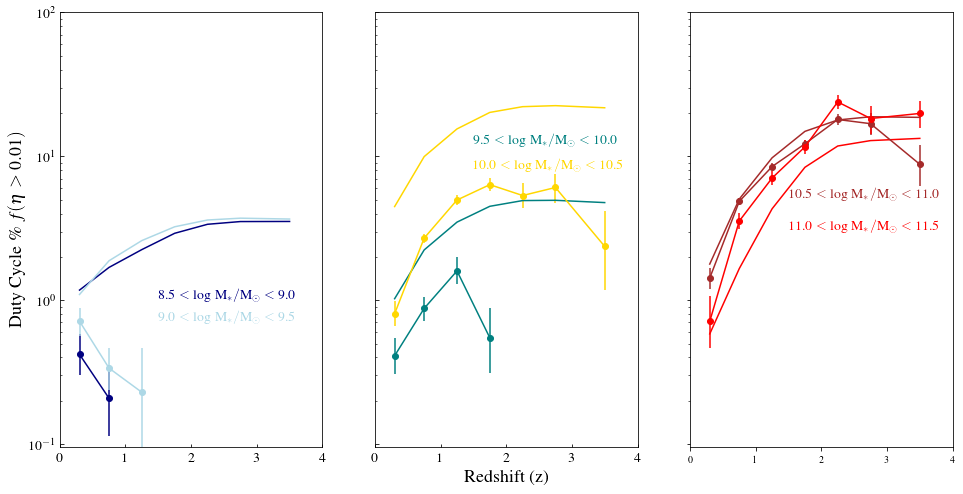

In [3]:
duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal = []
zl = []
zh = []
ml = []
mh = []
per = []
el = []
eh = []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1]))
        zh.append(float(s[2]))
        ml.append(float(s[3]))
        mh.append(float(s[4]))
        per.append(float(s[5]))
        el.append(float(s[6]))
        eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:] = el
yerr[1,:] = eh

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']

pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 10, 0.005
lums = np.linspace(5,18,200)

fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(16,8),sharey = True,sharex=True)
axes = [ax1, ax1, ax2, ax2, ax3, ax3]

for M, c, ax in zip(np.array(mass)+0.25,colors,axes):
    duty = []
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(lnM)
        qlf.get_Mbh(Mcrit, approx_local=True)
        qlf.get_dNdlnL(lums, [pre, post])

        lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
        sigs = qlf.Mdot_mu_sig[:,1] 
        lnstar = qlf.StellBins
        x = np.linspace(-25, 2, 2000)
        ind = np.argmin(np.abs(lnstar - M))
        y = ( 1/np.sqrt(2.0 * np.pi * sigs[ind]**2.0) ) * np.exp( -(x - lneta[ind])**2.0 / (2.0 * sigs[ind]**2) )
        duty.append(np.trapz(y[np.e**x>=0.01], x=x[np.e**x>=0.01])*100)
    ax.plot(ztot,duty ,c=c)



for i, c,ax in zip(mass,colors,axes):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]
    
    ax.errorbar(z, dut, yerr = err, fmt='o-', color = c)

ax1.text(1.5,1, r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', color='navy',fontsize=14)
ax1.text(1.5,.7, r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', color='lightblue',fontsize=14)
ax2.text(1.5,12, r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0', color='teal',fontsize=14)
ax2.text(1.5,8, r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', color='gold',fontsize=14)
ax3.text(1.5,5, r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', color='brown',fontsize=14)
ax3.text(1.5,3, r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5', color='red',fontsize=14)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle \% $f(\eta > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])
# ax1.set_yticks([0,1,10,100])

# ax1.xaxis.set_major_formatter(ScalarFormatter())

fig.savefig('plots/paper-plots/duty_cycle_varyzandmstar_v3.pdf')


/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/RESEARCH/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


[-0.8139988268104252, -0.6948068947763627, -0.6186055281056589, -0.5721790447310681, -0.5547745125438923, -0.553943068289538, -0.5609038430665766]
[-0.9863707722365119, -0.8353511468971315, -0.7308873826094253, -0.6588102122917081, -0.6314934738931914, -0.626532420262752, -0.6368301727358178]
[-1.0976320257352752, -0.9513592623417755, -0.8314817710731164, -0.7387527414509157, -0.6937524502219097, -0.6803441350482469, -0.6829097853152735]
[-1.2078977377566709, -1.097429696624122, -0.9662186676026949, -0.8508715568013583, -0.7811173301001489, -0.7619699033326802, -0.7539777579973372]


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/font_manager.py:1328: UserWarning: findfont: Font family ['serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


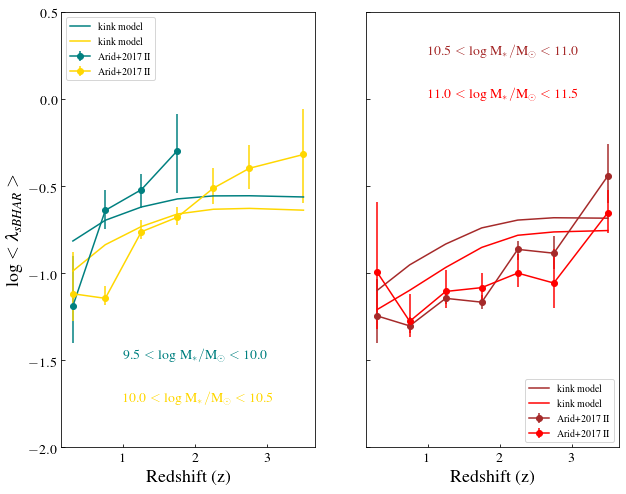

In [20]:
duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,8),sharey = True,sharex=True)
axes = [ax1, ax1, ax2, ax2]

from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

colors = ['teal', 'gold', 'brown', 'r']
for c,ax in zip(colors,axes):
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax.errorbar(x, y, yerr=yerr, fmt='o-', color = c, label='Arid+2017 II')
    ax.set_ylim([-2,0.5])
    
###########

mass = [9.5,10.0,10.5,11.0]
# mass = [[9.5,10.0],[10.0,10.5],[10.5,11.0],[11.0,11.5]]
ztot = [0.3,0.75,1.25,1.75,2.25,2.75,3.5]
pre, post, lnM, Mcrit, b = 4, 3.25, 0.7, 9.5, 0.005
lums = np.linspace(5,18,200)
    
for M, c, ax in zip(np.array(mass)+0.25,colors,axes):
    
    aveeta = []
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(lnM)
        qlf.get_Mbh(Mcrit, approx_local=True)
        qlf.get_dNdlnL(lums, [pre, post])
        
        lneta = qlf.Mdot_mu_sig[:,0] - qlf.Mdot_mu_sig[:,2]
        sigs = qlf.Mdot_mu_sig[:,1]
        ind = np.argmin(np.abs(qlf.StellBins - M))
        
        x = np.linspace(-25, 2, 2000)
        y = ( 1/np.sqrt(2.0 * np.pi * sigs[ind]**2.0) ) * np.exp( -(x - lneta[ind])**2.0 / (2.0 * sigs[ind]**2) )
        duty = np.trapz(y[np.e**x>=0.01], x=x[np.e**x>=0.01])
        
        aveeta.append(np.log10(np.sum(y[np.e**x>=0.01]*np.e**x[np.e**x>=0.01]*(x[1]-x[0]))/duty))
        
        
    
    print(aveeta)
    ax.plot(ztot, aveeta ,c=c, label='kink model')

###########
    
ax1.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.text(1.,-1.5, r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0', color='teal',fontsize=14)
ax1.text(1.,-1.75, r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', color='gold',fontsize=14)
ax2.text(1.,.25, r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', color='brown',fontsize=14)
ax2.text(1.,0, r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5', color='red',fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc ='lower right')
plt.savefig('plots/paper-plots/aveBHAR_varyzandmstar_v2.pdf')